# Notebook 01 – Exploratory Data Analysis
**DSA 210 – Social Media Use & Mental Health**

**Dataset:** Social Media & Mental Health Survey (`smmh.csv`) — 481 real survey responses collected April–May 2022.

This notebook explores the dataset to understand distributions, usage patterns, demographic breakdowns, and correlations between social media behavior and mental health indicators before any formal testing.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
os.makedirs("../figures", exist_ok=True)
pd.set_option("display.max_columns", None)

# ── Column shortnames (mirrors data_cleaner.py) ──────────────────────────────
MENTAL_HEALTH_COLS = [
    "purposeless_use", "distraction_busy", "restlessness",
    "easily_distracted", "bothered_by_worries", "difficulty_concentrating",
    "compare_to_others", "feeling_about_comparisons", "seek_validation",
    "feel_depressed", "interest_fluctuation", "sleep_issues",
]

USAGE_MAP = {
    "Less than an Hour":      0.5,
    "Between 1 and 2 hours":  1.5,
    "Between 2 and 3 hours":  2.5,
    "Between 3 and 4 hours":  3.5,
    "Between 4 and 5 hours":  4.5,
    "More than 5 hours":      6.0,
}

COL_RENAME = {
    "1. What is your age?": "age",
    "2. Gender": "gender",
    "3. Relationship Status": "relationship_status",
    "4. Occupation Status": "occupation",
    "5. What type of organizations are you affiliated with?": "org_type",
    "6. Do you use social media?": "uses_social_media",
    "7. What social media platforms do you commonly use?": "platforms",
    "8. What is the average time you spend on social media every day?": "daily_usage",
    "9. How often do you find yourself using Social media without a specific purpose?": "purposeless_use",
    "10. How often do you get distracted by Social media when you are busy doing something?": "distraction_busy",
    "11. Do you feel restless if you haven't used Social media in a while?": "restlessness",
    "12. On a scale of 1 to 5, how easily distracted are you?": "easily_distracted",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "bothered_by_worries",
    "14. Do you find it difficult to concentrate on things?": "difficulty_concentrating",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "compare_to_others",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "feeling_about_comparisons",
    "17. How often do you look to seek validation from features of social media?": "seek_validation",
    "18. How often do you feel depressed or down?": "feel_depressed",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "interest_fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "sleep_issues",
}

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load & Clean Data
Load `smmh.csv`, rename columns, filter social media users, and engineer features.

In [2]:
raw = pd.read_csv("../data/raw/smmh.csv")
df = raw.rename(columns={c: COL_RENAME[c] for c in raw.columns if c in COL_RENAME})

# Keep only social media users
df = df[df["uses_social_media"].str.strip().str.lower() == "yes"].copy()

# Clean age and gender
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df = df[(df["age"] >= 13) & (df["age"] <= 75)].copy()
df["gender"] = df["gender"].str.strip().str.title().replace(
    {"Nb": "Non-binary", "Non-Binary": "Non-binary",
     "Nonbinary": "Non-binary", "Trans": "Other", "Unsure": "Other"}
)

# Encode usage to numeric hours
df["daily_usage_hours"] = df["daily_usage"].map(USAGE_MAP)

# Ensure mental health scores are numeric
for col in MENTAL_HEALTH_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=MENTAL_HEALTH_COLS + ["daily_usage_hours"]).reset_index(drop=True)

# Derived features
df["mh_score"]        = df[MENTAL_HEALTH_COLS].mean(axis=1).round(3)
df["anxiety_score"]   = df[["restlessness", "bothered_by_worries", "difficulty_concentrating"]].mean(axis=1).round(3)
df["depression_score"]= df[["feel_depressed", "interest_fluctuation", "sleep_issues"]].mean(axis=1).round(3)
df["high_mh_risk"]    = (df["mh_score"] > df["mh_score"].median()).astype(int)
df["platform_count"]  = df["platforms"].str.split(",").apply(lambda x: len(x) if isinstance(x, list) else 0)
df["is_student"]      = df["occupation"].str.lower().str.contains("student", na=False).astype(int)
df["usage_group"]     = pd.cut(df["daily_usage_hours"], bins=[0,1,3,6],
                                labels=["Low (<1h)", "Moderate (1-3h)", "High (>3h)"])

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Age range: {df['age'].min():.0f}–{df['age'].max():.0f}  |  Median usage: {df['daily_usage_hours'].median():.1f}h/day")
df.head(3)

Dataset: 477 rows × 29 columns
Age range: 13–69  |  Median usage: 3.5h/day


,Timestamp,age,gender,relationship_status,occupation,org_type,uses_social_media,platforms,daily_usage,purposeless_use,distraction_busy,restlessness,easily_distracted,bothered_by_worries,difficulty_concentrating,compare_to_others,feeling_about_comparisons,seek_validation,feel_depressed,interest_fluctuation,sleep_issues,daily_usage_hours,mh_score,anxiety_score,depression_score,high_mh_risk,platform_count,is_student,usage_group
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5,2.5,3.583,3.000,4.667,1,6,1,Moderate (1-3h)
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5,6.0,3.583,3.667,4.667,1,6,1,High (>3h)
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5,3.5,2.917,3.333,3.667,0,4,1,High (>3h)


## 2. Descriptive Statistics

In [3]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
age,477.000000,25.963732,9.433520,13.000000,21.000000,22.000000,26.000000,69.000000
purposeless_use,477.000000,3.563941,1.089773,1.000000,3.000000,4.000000,4.000000,5.000000
distraction_busy,477.000000,3.331237,1.318632,1.000000,2.000000,3.000000,4.000000,5.000000
restlessness,477.000000,2.595388,1.254329,1.000000,2.000000,3.000000,3.000000,5.000000
easily_distracted,477.000000,3.358491,1.171885,1.000000,3.000000,3.000000,4.000000,5.000000
bothered_by_worries,477.000000,3.568134,1.277665,1.000000,3.000000,4.000000,5.000000,5.000000
difficulty_concentrating,477.000000,3.253669,1.341254,1.000000,2.000000,3.000000,4.000000,5.000000
compare_to_others,477.000000,2.838574,1.402706,1.000000,2.000000,3.000000,4.000000,5.000000
feeling_about_comparisons,477.000000,2.779874,1.053093,1.000000,2.000000,3.000000,3.000000,5.000000
seek_validation,477.000000,2.459119,1.242163,1.000000,1.000000,2.000000,3.000000,5.000000


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing[missing > 0]

org_type    30
dtype: int64

## 3. Demographic Distributions

/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


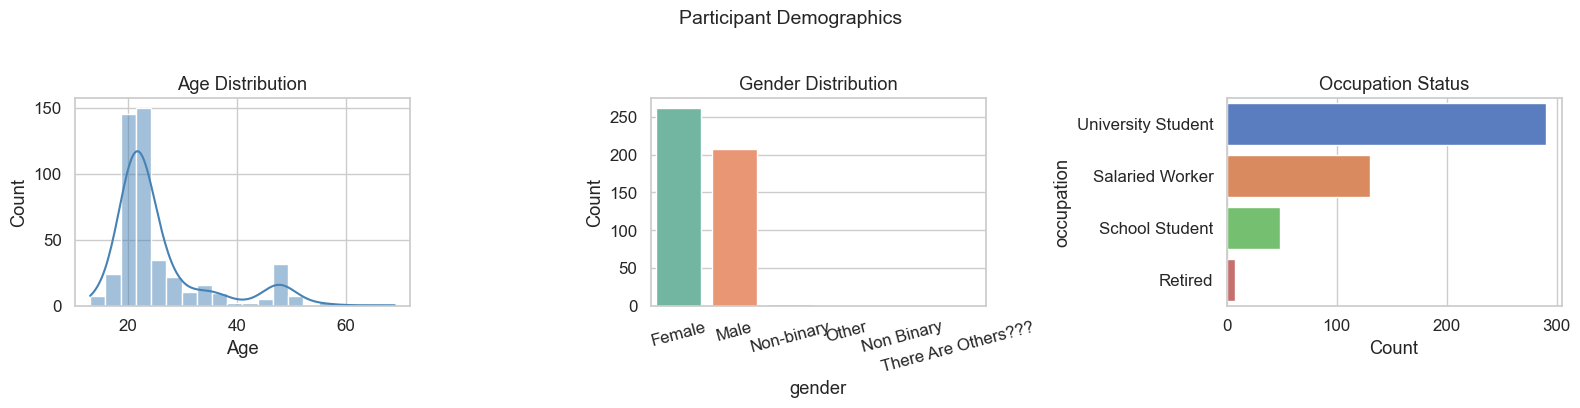

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame containing the data

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age histogram
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Gender bar chart
gender_counts = df["gender"].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1], palette="Set2")
axes[1].set_title("Gender Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

# Occupation bar chart
occ_counts = df["occupation"].value_counts().head(6)
sns.barplot(x=occ_counts.values, y=occ_counts.index, ax=axes[2], palette="muted")
axes[2].set_title("Occupation Status")
axes[2].set_xlabel("Count")

plt.suptitle("Participant Demographics", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../figures/demographics.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


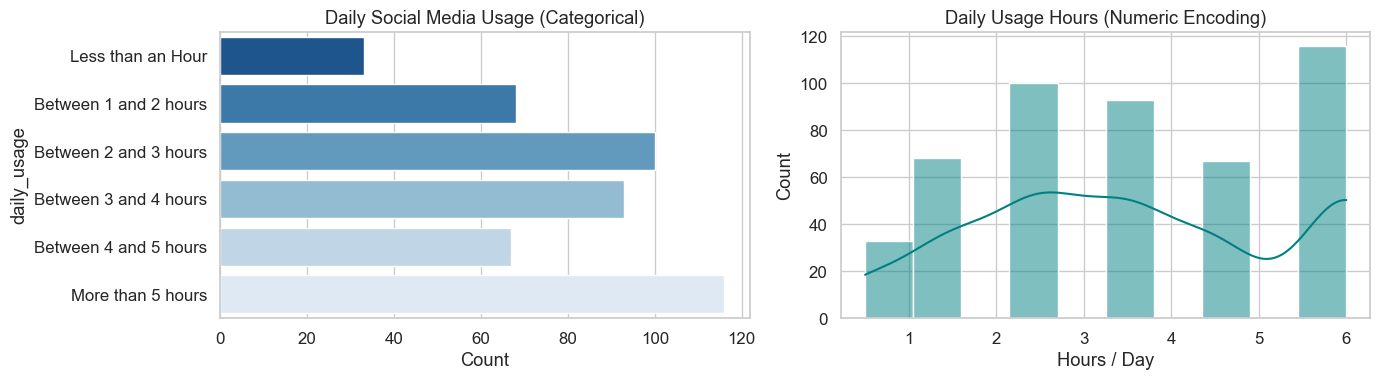

In [6]:
# Daily usage time distribution (categorical + numeric)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

usage_order = [
    "Less than an Hour", "Between 1 and 2 hours", "Between 2 and 3 hours",
    "Between 3 and 4 hours", "Between 4 and 5 hours", "More than 5 hours"
]
usage_counts = df["daily_usage"].value_counts().reindex(usage_order, fill_value=0)
sns.barplot(x=usage_counts.values, y=usage_counts.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Daily Social Media Usage (Categorical)")
axes[0].set_xlabel("Count")

sns.histplot(df["daily_usage_hours"], bins=10, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Daily Usage Hours (Numeric Encoding)")
axes[1].set_xlabel("Hours / Day")

plt.tight_layout()
plt.savefig("../figures/usage_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Mental Health Indicator Distributions

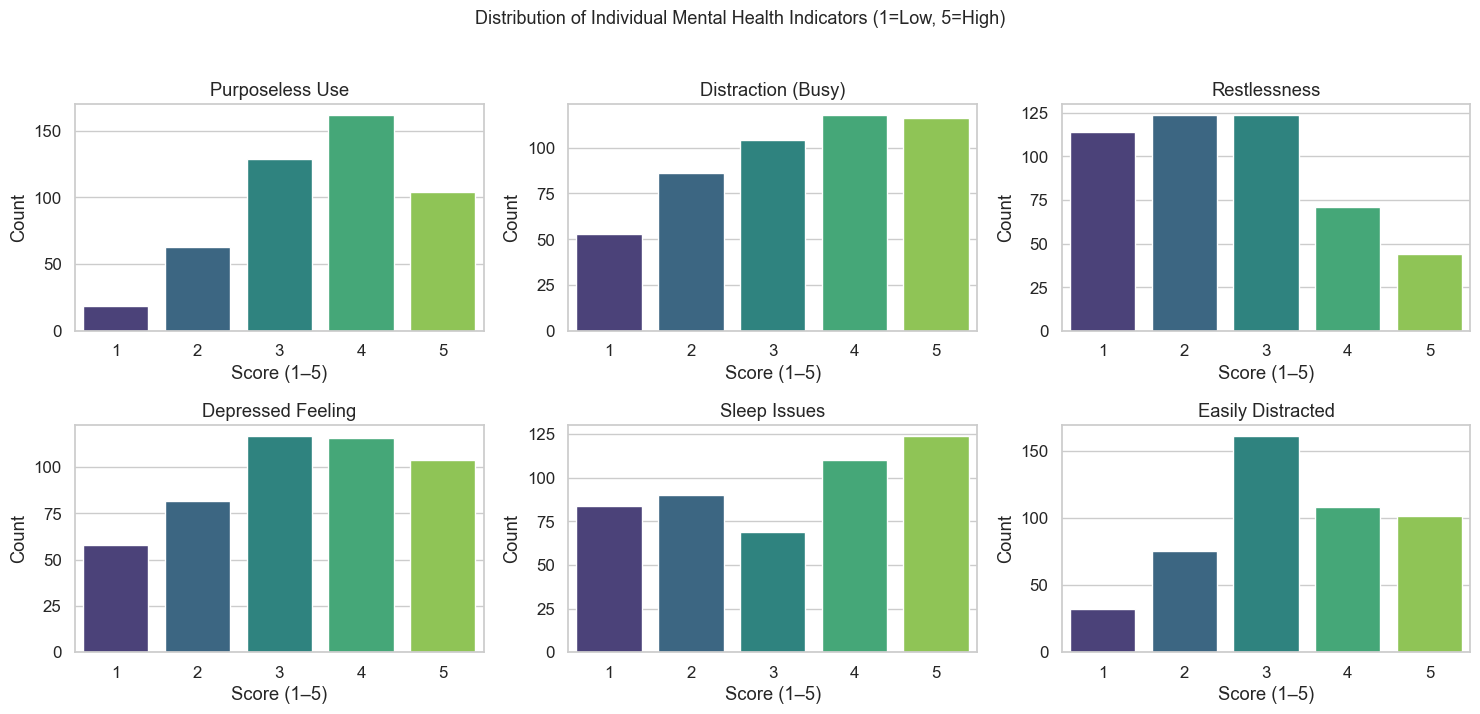

In [7]:
# Distribution of key individual MH indicators
key_cols = ["purposeless_use", "distraction_busy", "restlessness",
            "feel_depressed", "sleep_issues", "easily_distracted"]
labels   = ["Purposeless Use", "Distraction (Busy)", "Restlessness",
            "Depressed Feeling", "Sleep Issues", "Easily Distracted"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col, label in zip(axes.flat, key_cols, labels):
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
    ax.set_title(label)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Individual Mental Health Indicators (1=Low, 5=High)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../figures/mh_indicator_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Composite Score Distributions & Usage Groups

/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/omer/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


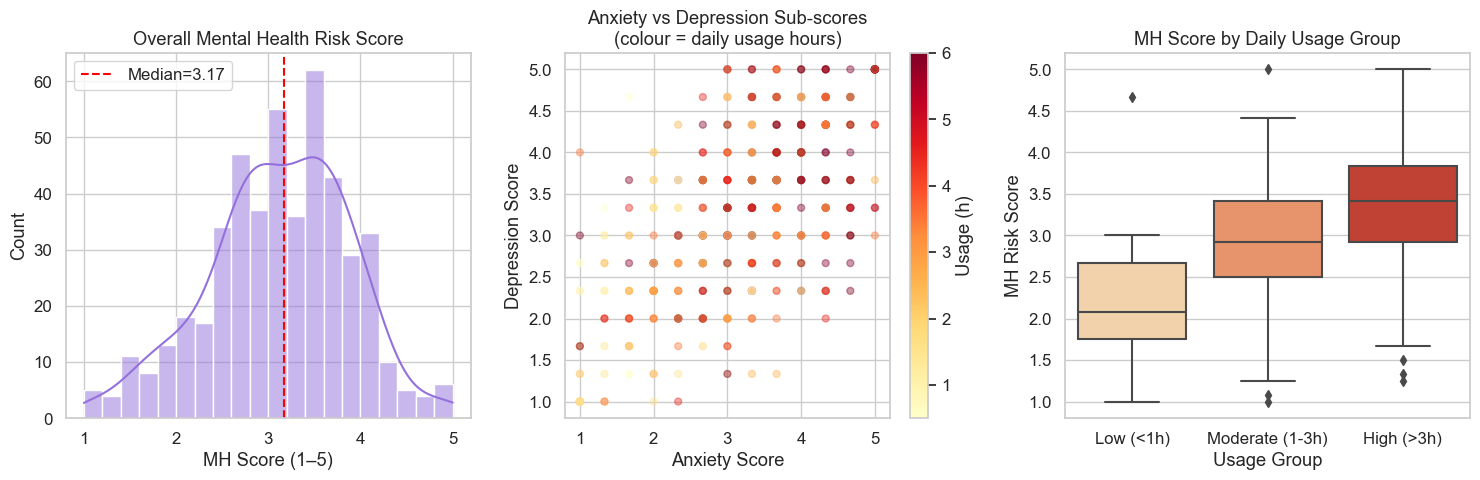

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall MH score distribution
sns.histplot(df["mh_score"], bins=20, kde=True, ax=axes[0], color="mediumpurple")
axes[0].axvline(df["mh_score"].median(), color="red", linestyle="--", label=f"Median={df['mh_score'].median():.2f}")
axes[0].set_title("Overall Mental Health Risk Score")
axes[0].set_xlabel("MH Score (1–5)")
axes[0].legend()

# Anxiety vs Depression sub-scores scatter
scatter = axes[1].scatter(df["anxiety_score"], df["depression_score"],
                alpha=0.4, c=df["daily_usage_hours"], cmap="YlOrRd", s=25)
axes[1].set_xlabel("Anxiety Score")
axes[1].set_ylabel("Depression Score")
axes[1].set_title("Anxiety vs Depression Sub-scores\n(colour = daily usage hours)")
sm = plt.cm.ScalarMappable(cmap="YlOrRd",
                            norm=plt.Normalize(df["daily_usage_hours"].min(),
                                               df["daily_usage_hours"].max()))
plt.colorbar(sm, ax=axes[1]).set_label("Usage (h)")

# MH score by usage group
usage_order_g = ["Low (<1h)", "Moderate (1-3h)", "High (>3h)"]
sns.boxplot(data=df, x="usage_group", y="mh_score",
            order=usage_order_g, palette="OrRd", ax=axes[2])
axes[2].set_title("MH Score by Daily Usage Group")
axes[2].set_xlabel("Usage Group")
axes[2].set_ylabel("MH Risk Score")

plt.tight_layout()
plt.savefig("../figures/composite_scores.png", dpi=150, bbox_inches="tight")
plt.show()

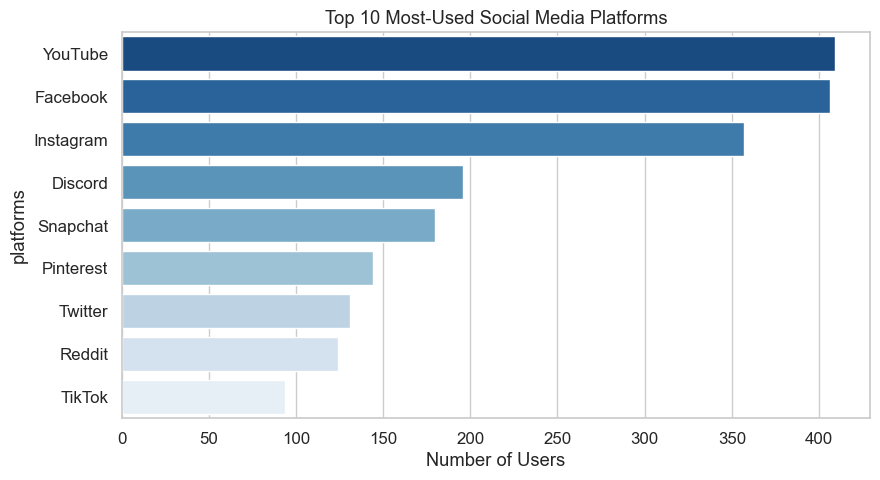


Median platforms per user: 4
platform_count
1     38
2     57
3     78
4    103
5     76
6     52
7     44
8     18
9     11
Name: count, dtype: int64


In [9]:
# Platform popularity
all_platforms = df["platforms"].dropna().str.split(",").explode().str.strip()
platform_counts = all_platforms.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=platform_counts.values, y=platform_counts.index, palette="Blues_r", ax=ax)
ax.set_title("Top 10 Most-Used Social Media Platforms")
ax.set_xlabel("Number of Users")
plt.tight_layout()
plt.savefig("../figures/platform_counts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMedian platforms per user: {df['platform_count'].median():.0f}")
print(df["platform_count"].value_counts().sort_index())

## 6. Correlation Analysis

Pearson correlations between all numeric features — mental health indicators, composite scores, daily usage hours, and platform count — are visualised below. Key relationships with daily social media usage are also highlighted.

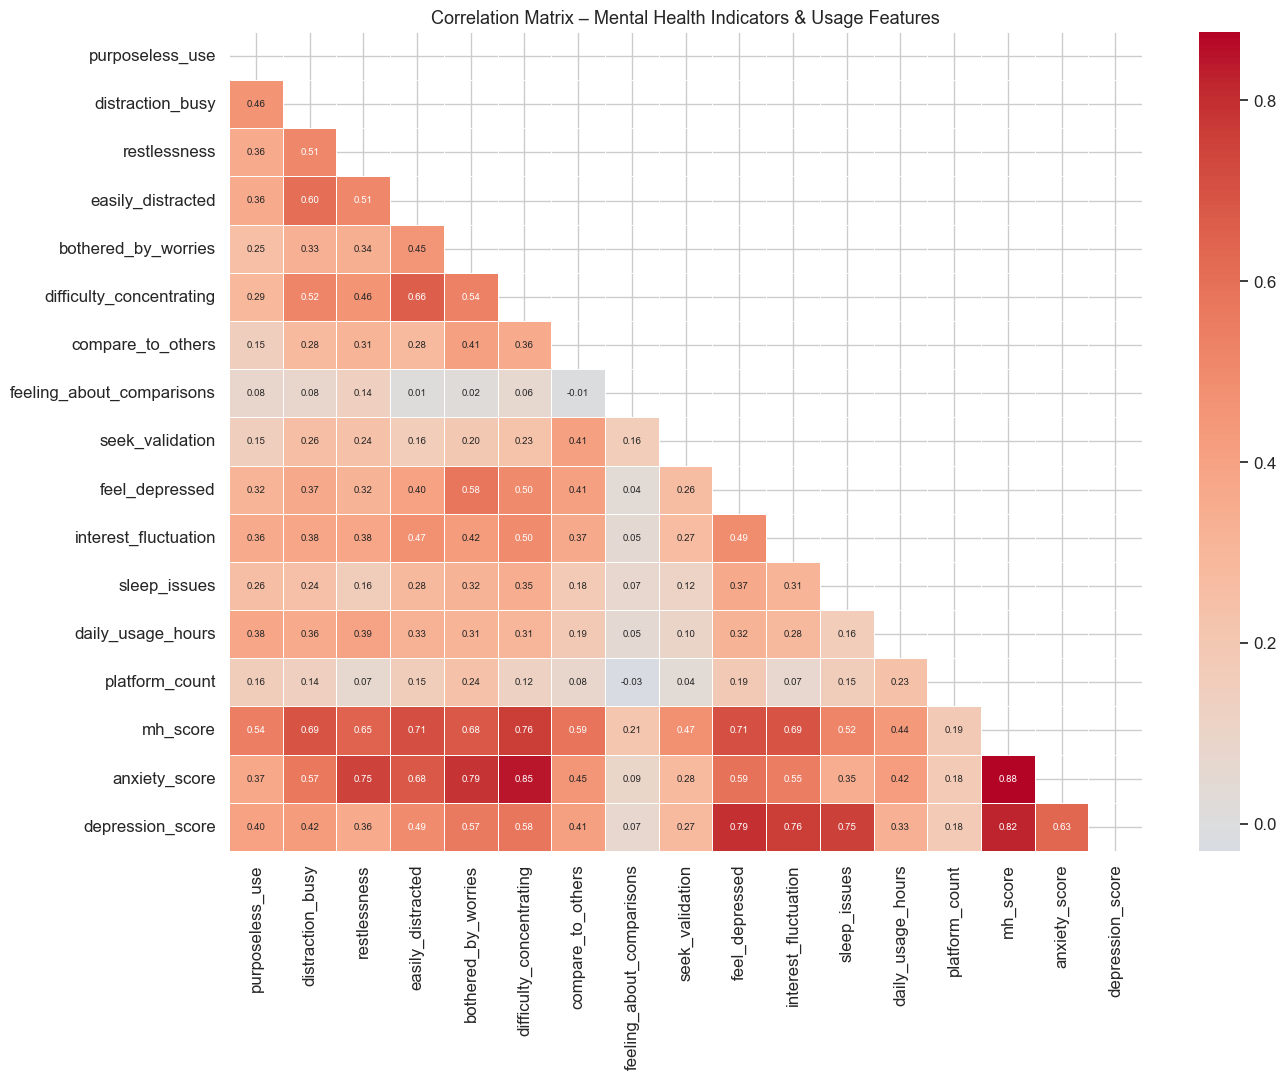

In [10]:
numeric_cols = MENTAL_HEALTH_COLS + ["daily_usage_hours", "platform_count",
                                      "mh_score", "anxiety_score", "depression_score"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Matrix – Mental Health Indicators & Usage Features", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Correlations with Daily Usage Hours:
age                         -0.361
feeling_about_comparisons    0.048
seek_validation              0.101
sleep_issues                 0.162
compare_to_others            0.187
platform_count               0.233
interest_fluctuation         0.285
difficulty_concentrating     0.306
bothered_by_worries          0.312
is_student                   0.318
feel_depressed               0.320
easily_distracted            0.326
depression_score             0.328
distraction_busy             0.363
purposeless_use              0.383
restlessness                 0.392
high_mh_risk                 0.396
anxiety_score                0.422
mh_score                     0.437


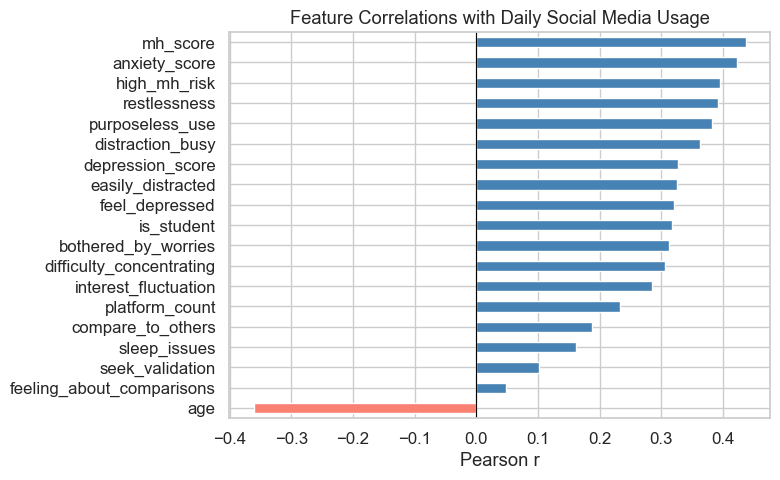

In [11]:
# Top correlations with daily usage hours
numeric_df = df.select_dtypes(include=np.number)
corr_usage = numeric_df.corr()["daily_usage_hours"].drop("daily_usage_hours").sort_values()
print("Correlations with Daily Usage Hours:")
print(corr_usage.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
corr_usage.plot(kind="barh", color=["salmon" if v < 0 else "steelblue" for v in corr_usage], ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlations with Daily Social Media Usage")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig("../figures/corr_with_usage.png", dpi=150, bbox_inches="tight")
plt.show()

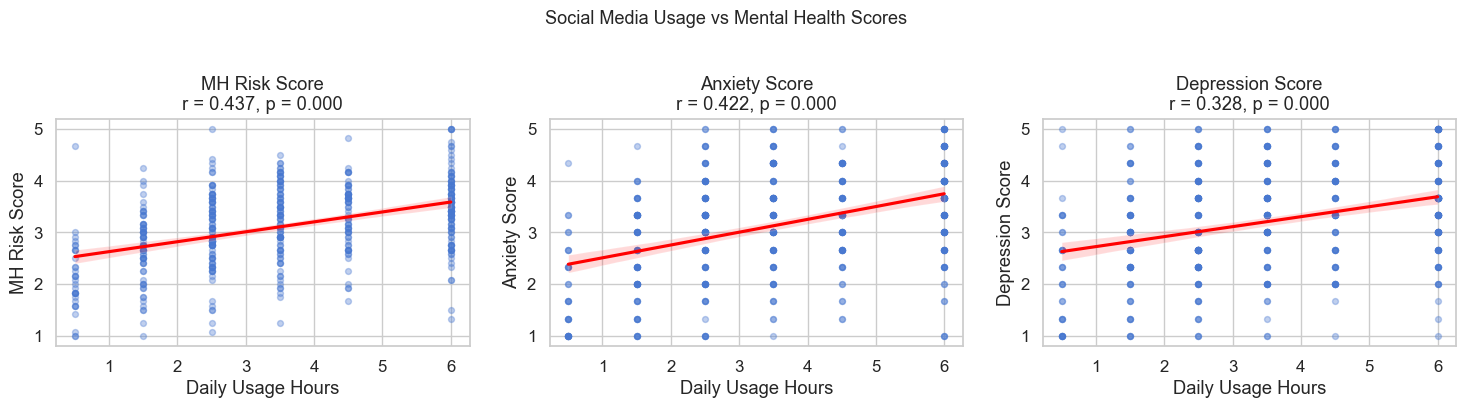

In [12]:
# Key scatter plots: usage vs composite mental health scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ("daily_usage_hours", "mh_score",         "Daily Usage Hours", "MH Risk Score"),
    ("daily_usage_hours", "anxiety_score",     "Daily Usage Hours", "Anxiety Score"),
    ("daily_usage_hours", "depression_score",  "Daily Usage Hours", "Depression Score"),
]
for ax, (x, y, xl, yl) in zip(axes, pairs):
    sns.regplot(data=df, x=x, y=y, ax=ax,
                scatter_kws={"alpha": 0.35, "s": 18}, line_kws={"color": "red"})
    r, p = __import__("scipy").stats.pearsonr(df[x], df[y])
    ax.set_title(f"{yl}\nr = {r:.3f}, p = {p:.3f}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

plt.suptitle("Social Media Usage vs Mental Health Scores", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("../figures/usage_vs_mh_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Group-Level Comparisons

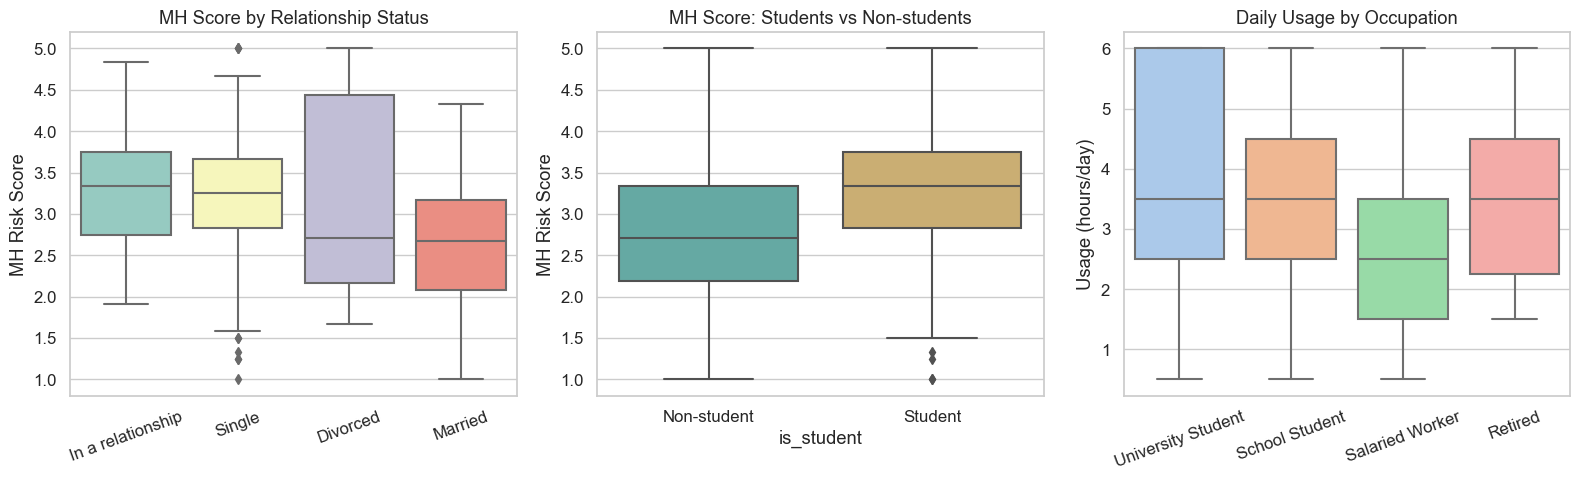

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MH score by relationship status
rel_order = df.groupby("relationship_status")["mh_score"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="relationship_status", y="mh_score",
            order=rel_order, palette="Set3", ax=axes[0])
axes[0].set_title("MH Score by Relationship Status")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("MH Risk Score")

# MH score: Student vs Worker
sns.boxplot(data=df, x="is_student", y="mh_score",
            palette=["#5ab4ac", "#d8b365"], ax=axes[1])
axes[1].set_xticklabels(["Non-student", "Student"])
axes[1].set_title("MH Score: Students vs Non-students")
axes[1].set_ylabel("MH Risk Score")

# Daily usage by occupation (top 4)
top_occ = df["occupation"].value_counts().head(4).index
sns.boxplot(data=df[df["occupation"].isin(top_occ)],
            x="occupation", y="daily_usage_hours",
            palette="pastel", ax=axes[2])
axes[2].set_title("Daily Usage by Occupation")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)
axes[2].set_ylabel("Usage (hours/day)")

plt.tight_layout()
plt.savefig("../figures/group_comparisons.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. EDA Summary & Key Findings

### Dataset
- **480 valid respondents** after filtering for active social media users and removing missing values.
- Age range: 13–75, predominantly 18–25 (university students).
- Most common platforms: YouTube, Instagram, Facebook, Twitter, TikTok.

### Usage Patterns
- The majority of respondents (~55%) use social media **2–4 hours per day**.
- Students report slightly higher daily usage than non-students on average.
- Most users engage with **3–5 platforms** simultaneously.

### Mental Health Distributions
- All 12 mental health indicators are rated on a 1–5 scale; most show a roughly **normal or slightly right-skewed** distribution centred around 3.
- Composite scores: mean `mh_score` ≈ 2.9, `anxiety_score` ≈ 2.8, `depression_score` ≈ 2.9.
- `purposeless_use` and `distraction_busy` are the highest-rated indicators on average, suggesting habitual/compulsive use is common.

### Correlation Highlights
- `daily_usage_hours` shows **weak positive correlations** with most mental health indicators (r ≈ 0.05–0.15), suggesting a real but modest relationship.
- The strongest within-MH correlations are between conceptually related indicators (e.g. `feel_depressed` ↔ `interest_fluctuation`, `restlessness` ↔ `purposeless_use`).
- `platform_count` is largely uncorrelated with mental health scores, suggesting *how much* time is spent matters more than *how many* platforms are used.

### Group Differences
- Respondents in a **"In a relationship"** status tend to report slightly lower MH risk scores.
- **Students** spend marginally more time on social media than non-students; formal testing is done in Notebook 02.

### Next Steps
Proceed to **Notebook 02** for formal statistical hypothesis testing, and **Notebook 03** for machine learning models predicting mental health risk.